# Diabetes Dataset For Data Preprocessing Practice

In [28]:
# Step 1: Import Libraries and Load Dataset
# Dataset Column Means:
# • Pregnancies: Number of times the patient has been pregnant.
# • Glucose: Plasma glucose concentration measured during an oral glucose tolerance test.
# • BloodPressure: Diastolic blood pressure in mm Hg.
# • SkinThickness: Triceps skinfold thickness in millimeters, a measure of body fat.
# • Insulin: Serum insulin level in µU/mL.
# • BMI: Body Mass Index calculated as weight (kg) / height (m²).
# • DiabetesPedigreeFunction: A score estimating the likelihood of diabetes based on family history.
# • Age: Patient’s age in years.
# • Outcome: Diabetes diagnosis indicator (1 = diabetic, 0 = non‑diabetic).

import pandas as pd
import numpy as np
from Demos.getfilever import n
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../../../../0-Dataset_And_Playground/1-AI-Dataset/diabetes.csv')
df.head(n=10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [29]:
# Step 2: Inspect Data Structure and Check Missing Values
# - We understand dataset size, data types and identify any incomplete (missing) data that needs handling.
# - df.info(): Prints concise summary including count of non-null entries and data type of each column.
# - df.isnull().sum(): Returns the number of missing values per column.

df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0


In [30]:
# Step 3-1: Statistical Summary  
# - Get numeric summaries like mean, median, min/max and detect unusual points (outliers). 
# - df.describe(): Computes count, mean, std deviation, min/max and quartiles for numerical columns.

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


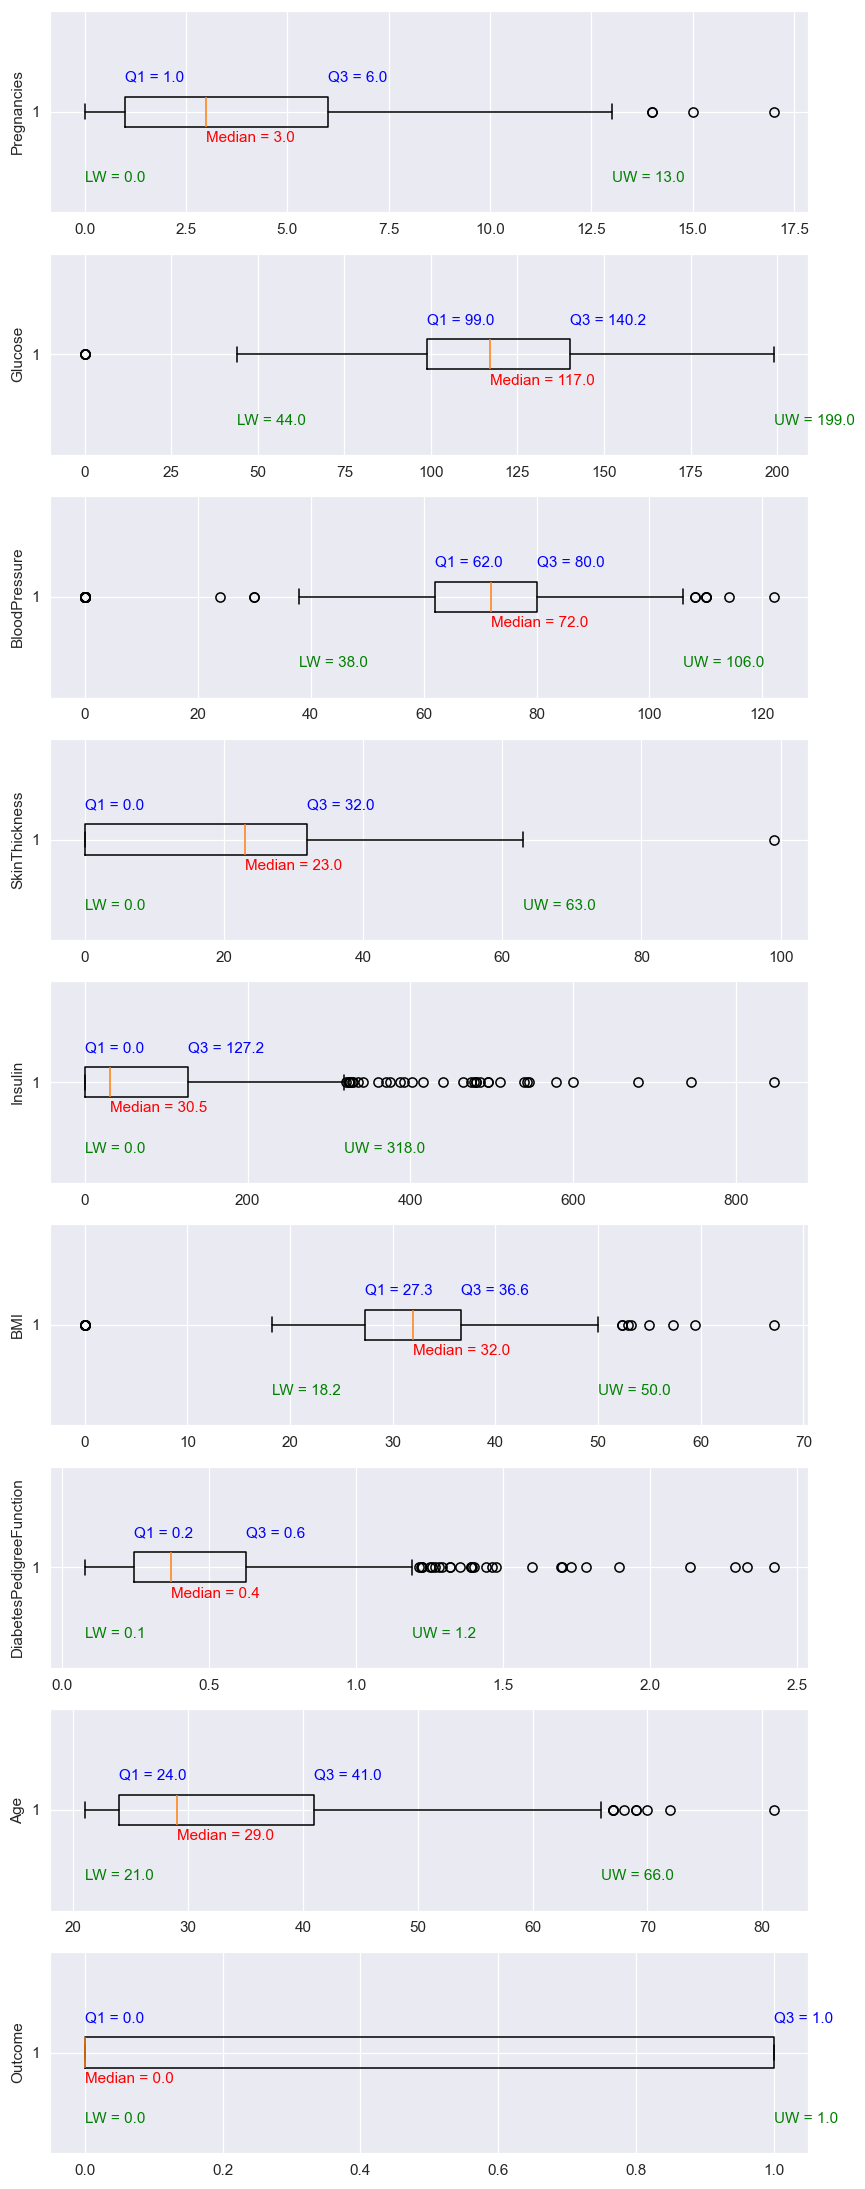

In [31]:
# Step 3-2: Visualizing Outliers
# - Outliers can skew models if not handled.
# - Boxplots: Visualize spread and detect outliers using matplotlib’s boxplot().
# - Boxplots Include: 1-Minimum 2-Q1 (25th percentile) 3-Median(50th percentile) 4-Q3(75th percentile) 5-Maximum
# - Boxplot components:
# -- Middle line of the box = Median
# -- Left edge of the box = Q1 (First Quartile)
# -- Right edge of the box = Q3 (Third Quartile)
# -- Outer lines (whiskers) extend to the data points that are not outliers
# -- Separate points = Outliers
# - That is, each point lying outside the range:
# -- Q1 − 1.5 × IQR to Q3 + 1.5 × IQR
# - So Boxplot quickly tells you:
# -- Where is the center of the data?
# -- How spread out is the data?
# -- Are the data straight or skewed?
# -- Do we have outliers?
# -- What is the range of the data?


# Form 1 (Simple Boxplot):
# fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
# for i, col in enumerate(df.columns):
#     axs[i].boxplot(df[col], vert=False)
#     axs[i].set_ylabel(col)
# plt.tight_layout()
# # plt.savefig("boxplots.png") # Export as image 
# plt.show()


# Form 2(Create Boxplot with complete label):
fig, axs = plt.subplots(len(df.columns), 1, figsize=(8, 20), dpi=110)
for i, col in enumerate(df.columns):
    data = df[col].dropna()
    # Calculate statistics
    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_whisker = max(data[data >= q1 - 1.5 * iqr].min(), data.min())
    upper_whisker = min(data[data <= q3 + 1.5 * iqr].max(), data.max())
    # Draw boxplot
    axs[i].boxplot(data, vert=False)
    # Add labels
    axs[i].text(q1, 1.15, f"Q1 = {q1:.1f}", color="blue")
    axs[i].text(median, 0.85, f"Median = {median:.1f}", color="red")
    axs[i].text(q3, 1.15, f"Q3 = {q3:.1f}", color="blue")
    axs[i].text(lower_whisker, 0.65, f"LW = {lower_whisker:.1f}", color="green")
    axs[i].text(upper_whisker, 0.65, f"UW = {upper_whisker:.1f}", color="green")
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()


# Form 3(Boxplot with show number):
# fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
# for i, col in enumerate(df.columns):
#     data = df[col].dropna()
#     # Calculate 5-point summary
#     minimum = np.min(data)
#     q1 = np.percentile(data, 25)
#     median = np.percentile(data, 50)
#     q3 = np.percentile(data, 75)
#     maximum = np.max(data)
#     # Print results
#     print(f"=== {col} ===")
#     print(f"Minimum: {minimum}")
#     print(f"Q1 (25%): {q1}")
#     print(f"Median (50%): {median}")
#     print(f"Q3 (75%): {q3}")
#     print(f"Maximum: {maximum}\n")
#     # Plot boxplot
#     axs[i].boxplot(data, vert=False)
#     axs[i].set_ylabel(col)
# plt.tight_layout()
# plt.show()

In [32]:
# Step 4: Remove Outliers Using the Interquartile Range (IQR) Method
# - Remove extreme values beyond a reasonable range to improve model robustness.
# - IQR = Q3 (75th percentile) – Q1 (25th percentile).
# - Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.
# - Calculate lower and upper bounds for each column separately.
# - Filter data points to keep only those within bounds

q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]

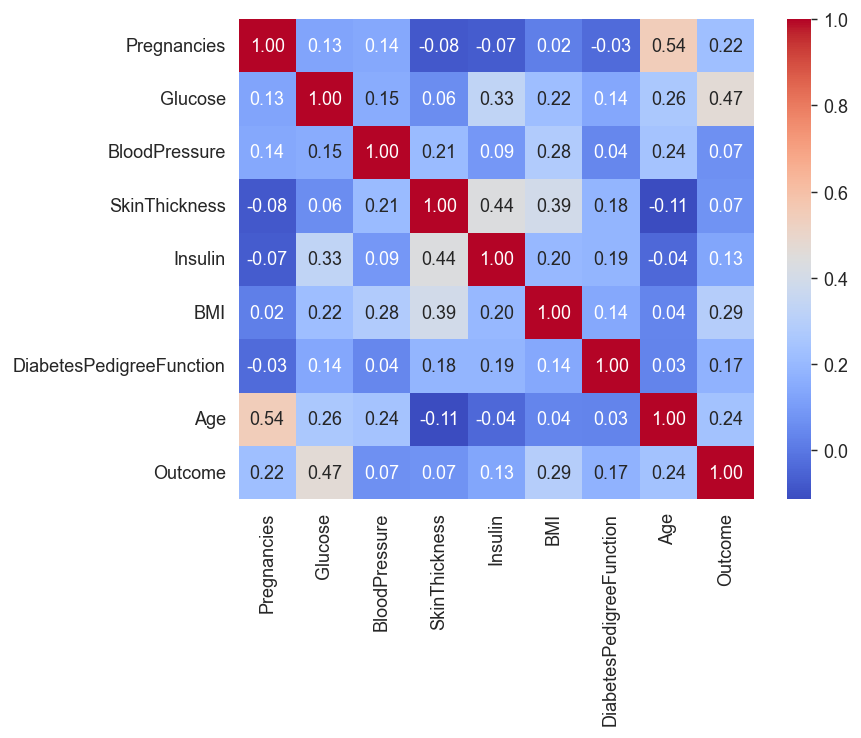

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [33]:
# Step 5: Correlation Analysis
# - Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.
# - df.corr(): Computes pairwise correlation coefficients between columns.
# - Heatmap via seaborn visualizes correlation matrix clearly.
# - Sorting correlations: with corr['Outcome'].sort_values() highlights features most correlated with the target.

corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
# plt.savefig("cor.png") # Export as image 
plt.show()

print(corr['Outcome'].sort_values(ascending=False))

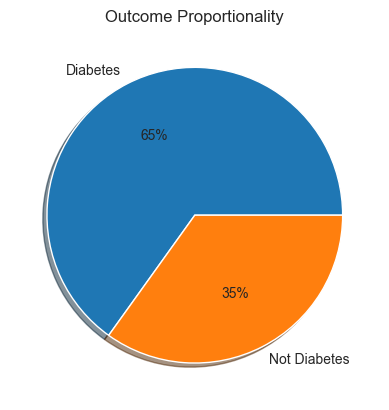

In [34]:
# Step 6: Visualize Target Variable Distribution
# - Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.
# - plt.pie(): Pie chart to display proportion of each class in the target variable 'Outcome'.

plt.pie(df['Outcome'].value_counts(), labels=[
        'Diabetes', 'Not Diabetes'], autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')
plt.show()

In [35]:
# Step 7: Separate Features and Target Variable
# - Prepare independent variables (features) and dependent variable (target) separately for modeling.
# - df.drop(columns=[...]): Drops the target column from features.
# - Direct column selection df['Outcome'] selects target column.

X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [36]:
# Step 8-1: Feature Scaling: Normalization and Standardization
# - Scale features to a common range or distribution, important for many ML algorithms sensitive to feature magnitudes.

# 1. Normalization (Min-Max Scaling): Rescales features between
# - Rescales features between 0 and 1. Good for algorithms like k-NN and neural networks.
# - Class: MinMaxScaler from sklearn.
# - .fit_transform(): Learns min/max from data and applies scaling.

# scaler = MinMaxScaler()
# X_normalized = scaler.fit_transform(X)
# print(X_normalized[:5])


# 2. Standardization: 
# - Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features.
# - Class: StandardScaler from sklearn.

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]
